In [5]:
from scipy.stats import norm
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from class_imbalance_experiment.util import run_experiment, multiclass_imbalance_ratio

# Seed for reproducibility
np.random.seed(42)

# Number of samples
n_samples = 10000

# Unimodal class distribution (peak at class 3)
class_distribution = [0.03, 0.07, 0.8, 0.07, 0.03]
classes = np.arange(1, 6)

le = LabelEncoder()
le.fit(classes)

# Generate target variable
#y = np.random.choice(classes, size=n_samples, p=class_distribution)

# Latent variable
z = np.random.normal(0, 1.0, n_samples)

# Find thresholds according to distribution
cum_probs = np.cumsum(class_distribution)
thresholds = np.concatenate(([-np.inf],norm.ppf(cum_probs)))
print(thresholds)

y = np.searchsorted(thresholds, z, side="right")

print("Imbalance Ratio (IR) ", multiclass_imbalance_ratio(y))

# --- Features with stronger correlation and less noise ---
# X1 = y + np.random.normal(0, 0.8, n_samples)         # main ordinal signal
# X2 = 0.5 * y + np.random.normal(0, 0.5, n_samples)   # linear relation
# X3 = np.sin(y) + np.random.normal(0, 0.5, n_samples) # nonlinear but correlated
# X4 = 0.3 * y + np.random.normal(0, 0.8, n_samples)   # mild linear relation
# #X5 = y**0.8 + np.random.normal(0, 0.4, n_samples)    # curved but predictive

#X1 = y + np.random.normal(0, 1.0, n_samples)    # noisy ordinal relation
#X2 = np.sin(y) + np.random.normal(0, 1.0, n_samples) # nonlinear but correlated
#X3 = np.random.normal(0, 1.0, n_samples)           # mostly noise
#X4 = 0.5 * y + np.random.normal(0, 1.0, n_samples)

# X1 = y + np.random.normal(0, 0.8, n_samples)  # main ordinal signal
# X2 = np.sin(y) + np.random.normal(0, 1.0, n_samples)  # nonlinear but correlated
# X3 = 0.3 * y + np.random.normal(0, 0.3, n_samples)   # mild relation
# X4 = 0.5 * y + np.random.normal(0, 1.0, n_samples) # linear relation

# Create features
X1 = z + np.random.normal(0, 1.0, n_samples)
X2 = np.sin(z) + np.random.normal(0, 1.0, n_samples)
X3 = 0.8 * z + np.random.normal(0, 0.2, n_samples)
X4 = 0.5 * z + np.random.normal(0, 0.3, n_samples)

# Combine into DataFrame
data = pd.DataFrame({
    'feature_1': X1,
    'feature_2': X2,
    'feature_3': X3,
    'feature_4': X4,
    'class': y
})

# Assuming `data` DataFrame exists
X = data.drop(columns='class')
y = data['class']






[       -inf -1.88079361 -1.28155157  1.28155157  1.88079361         inf]
Imbalance Ratio (IR)  26.17377049180328


In [6]:
# Overall class distribution
print("\nClass distribution in full dataset:")
print(data['class'].value_counts(normalize=True).sort_index())


Class distribution in full dataset:
class
1    0.0307
2    0.0710
3    0.7983
4    0.0695
5    0.0305
Name: proportion, dtype: float64


C:\Users\Q454199\projects\ordinal-aleatoric-epistemic-uncertainty\class_imbalance_experiment\util.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x=[1,2,3,4,5],y=p,legend=False,palette=colors)


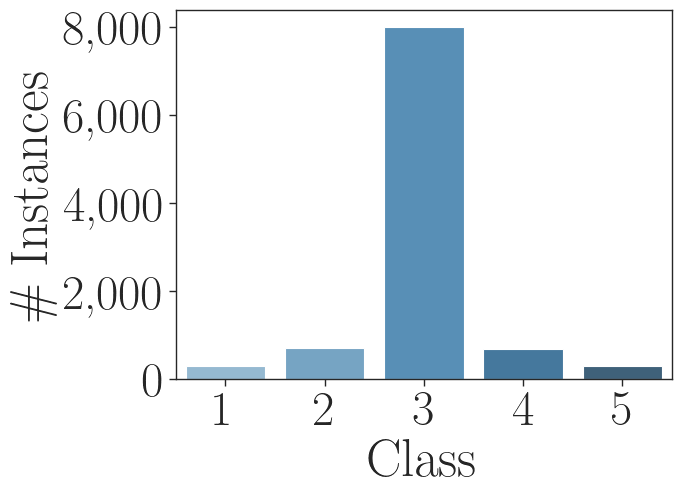

In [9]:
from class_imbalance_experiment.util import plot_data_dist

plot_data_dist(data['class'].value_counts(normalize=False).sort_index().values , "unimodal")

In [8]:
run_experiment(X, y, le, "unimodal")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 4
[LightGBM] [Info] Start training from score -3.484579
[LightGBM] [Info] Start training from score -2.645075
[LightGBM] [Info] Start training from score -0.225368
[LightGBM] [Info] Start training from score -2.665629
[LightGBM] [Info] Start training from score -3.488209
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 9000, number of used features: 4
[Light